In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/customer_pca.csv')
data.head()

,amt,category_entertainment,category_food_dining,category_gas_transport,category_grocery,category_health_fitness,category_home,category_kids_pets,category_misc,category_personal_care,category_shopping,category_travel,label
0,-1.402327,-1.135617,-0.971069,-1.000180,-1.118217,-1.561756,-1.145051,-1.276913,-1.124693,-1.070260,-1.141424,-0.619930,0
1,1.079407,0.414075,0.168880,2.090013,0.767268,1.040236,0.844969,1.127922,1.210503,1.807350,0.659967,-0.222587,3
2,1.200151,0.747127,1.622968,-0.606627,0.439476,1.376630,2.126364,0.378610,-0.196523,0.127825,1.299938,2.766891,1
3,-1.474915,-1.129427,-1.539741,-0.930355,-1.079803,-1.222903,-1.572733,-1.516610,-1.274986,-1.185705,-1.166127,-0.601675,0
4,0.901491,0.257905,-0.320220,2.083588,0.540547,0.705908,1.097814,0.955178,1.198524,1.640103,0.578781,-0.484796,3


In [3]:
x = data.drop('label',axis=1)
y = data['label']

In [4]:
# 2차원 평면의 그래프를 그리는 것이 목적이기 때문에
pca = PCA(n_components=2)

In [5]:
pca.fit(x) # 학습
customer_pca=pca.transform(x) # 변환

In [6]:
customer_pca

array([[-3.92906072e+00,  1.02604491e-01],
       [ 3.10758276e+00, -1.74887930e+00],
       [ 3.02379272e+00,  3.21221215e+00],
       [-4.28241767e+00,  1.13781030e-02],
       [ 2.59065802e+00, -1.90612064e+00],
       [ 8.70343520e-01, -1.79154348e-02],
       [-1.16508938e+00,  2.00387900e+00],
       [ 1.41163657e+00, -1.21220170e+00],
       [ 1.79302072e-01, -1.15337545e+00],
       [-2.74166293e+00, -3.48112299e-02],
       [ 4.03108363e-01, -2.56426911e-01],
       [-4.32816586e+00,  1.09280479e-01],
       [-1.06779010e+00, -4.71336448e-01],
       [-3.54208654e+00,  2.09373453e-01],
       [ 3.00321739e+00,  6.85140300e-02],
       [ 5.08464052e+00, -1.92234923e+00],
       [-1.39044460e+00,  3.22162225e-01],
       [-2.64318989e+00, -4.59744830e-01],
       [-7.37714393e-01, -9.30393910e-01],
       [-3.93420145e+00,  1.62749639e-01],
       [ 3.16675507e-01, -4.22288613e-01],
       [ 7.31864853e+00,  5.17885391e-02],
       [ 6.60448573e-01, -1.13828656e+00],
       [-3.

In [7]:
customer_pca = pd.DataFrame(customer_pca,columns=['PC1','PC2'])

In [8]:
# 변환된 데이터프레임에 기존 데이터의 목표값이 label 붙임.

customer_pca = customer_pca.join(y)

<Axes: xlabel='PC1', ylabel='PC2'>

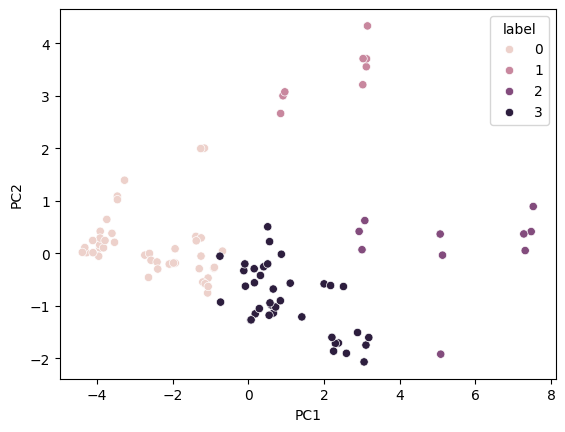

In [9]:
sns.scatterplot(x='PC1',y='PC2',data=customer_pca,hue='label')

In [10]:
# 주성분과 기존의 변수와의 상관관계를 확인
df_comp=pd.DataFrame(pca.components_, columns=x.columns)
df_comp.T

,0,1
amt,0.348468,0.058276
category_entertainment,0.324472,0.060343
category_food_dining,0.303037,0.152647
category_gas_transport,0.141869,-0.544356
category_grocery,0.306183,0.031095
category_health_fitness,0.312973,0.037906
category_home,0.297189,0.238096
category_kids_pets,0.304582,-0.231528
category_misc,0.293413,-0.247193
category_personal_care,0.302877,-0.208983


<Axes: >

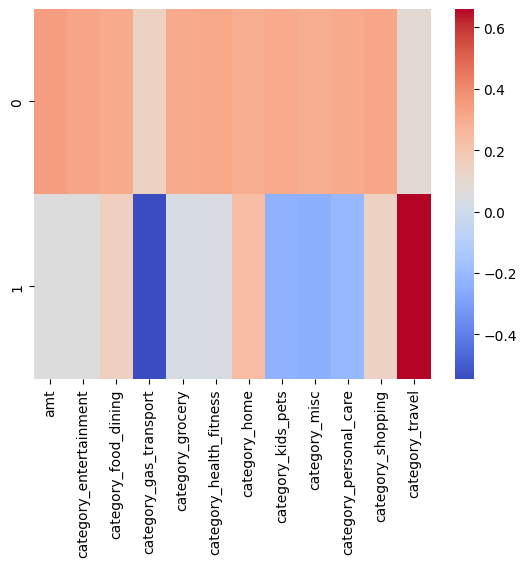

In [11]:
# 양수면 빨간색, 음수면 파란색 계열로 표현
sns.heatmap(df_comp,cmap='coolwarm')

# 다차원 데이터 차원 축소

- 차원을 축소해서 모델학습 속도를 높일수 있음
- 반대로 과도하게 차원이 축소하면 예측 결과가 나빠짐
- 차원의 축소가 속도와 성능에 어떠한 영향을 끼치는지

In [12]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/anonymous.csv')
data.head()

,class,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V4287,V4288,V4289,V4290,V4291,V4292,V4293,V4294,V4295,V4296
0,1,0.0,0.0,0.56758,0.0,0.0,0.0,0.0,0.82585,0.83788,...,-0.25777,0.12220,0.348620,0.12957,0.43846,-0.108020,0.128330,0.318820,-0.041559,0.22589
1,1,0.0,0.0,0.56758,0.0,0.0,0.0,0.0,0.82585,0.83788,...,-0.15316,0.14062,-0.030201,0.10134,-0.14546,-0.166650,0.401300,0.035392,0.019906,0.31952
2,1,0.0,0.0,0.56758,0.0,0.0,0.0,0.0,0.82585,0.83788,...,-0.40122,0.13790,0.138350,0.15746,0.51216,-0.330690,0.070346,0.179250,-0.188740,0.16386
3,1,0.0,0.0,0.56758,0.0,0.0,0.0,0.0,0.82585,0.83788,...,-0.15587,-0.26686,0.158930,-0.13204,0.32221,-0.042086,0.588970,0.526990,-0.574320,0.20891
4,1,0.0,0.0,0.56758,0.0,0.0,0.0,0.0,0.82585,0.83788,...,0.24020,0.44605,-0.163560,0.45311,0.59073,0.356800,0.395780,0.035871,-0.293430,0.38124


In [13]:
data['class'].mean(0)

np.float64(0.25)

In [14]:
data.isna().sum().sum()

np.int64(0)

In [16]:
x = data.drop(columns='class')
y = data['class']

In [17]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=100)

In [19]:
# pca변수간의 스케일을 일정학 맞추는것도 중요
# 모델링 전에 standardscalen로 맞춤

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# 랜덤 포레스트를 사용해서 시간 체크
from sklearn.ensemble import RandomForestClassifier
model_1 = RandomForestClassifier(random_state=100)

In [22]:
import time

start_time = time.time()
model_1.fit(X_train_scaled,y_train)
print(time.time()-start_time)

177.3415961265564


In [23]:
# 정확도 확인
from sklearn.metrics import accuracy_score,roc_auc_score

pred_1 = model_1.predict(X_test_scaled)
accuracy_score(y_test,pred_1)

0.958

### AUC란?
->  데이터셋이 불균형일때 모델의 실제성능을 가장 정직하게 반영하는 것.  
->  소수점 형태로 된 예측값을 사용하기 때문에, 이진 분류모델의 성능을 평가하는데 중요한 척도

  - predict_proba()
  - predict : 분류 예측결과
  - predict_proba : 예측 확률

In [25]:
# AUC 확인
proba_1 = model_1.predict_proba(X_test_scaled)
roc_auc_score(y_test,proba_1[:,1])

np.float64(0.9982541957107813)